INICIANDO FASE 1: TESTE DE VALIDAÇÃO MATEMÁTICA (Impulso)
✅ TESTE APROVADO!
   Erro na frequência (Item b): 0.00e+00
   Erro no tempo (Item c)     : 0.00e+00
   Os cálculos de DFT, Zero-Padding e Subamostragem estão consistentes.

INICIANDO FASE 2: PROCESSAMENTO DO ÁUDIO (Questão 4)
Por favor, faça o upload do arquivo 'forcewithyou.wav' (ou outro .wav equivalente):


Saving forcewithyou.wav to forcewithyou (4).wav

--- Gerando gráficos para: Áudio wav ---


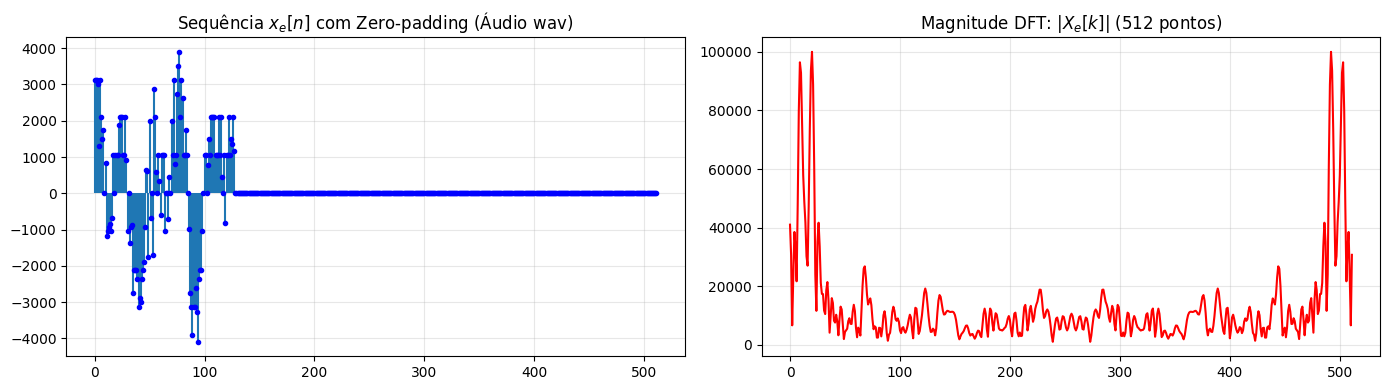

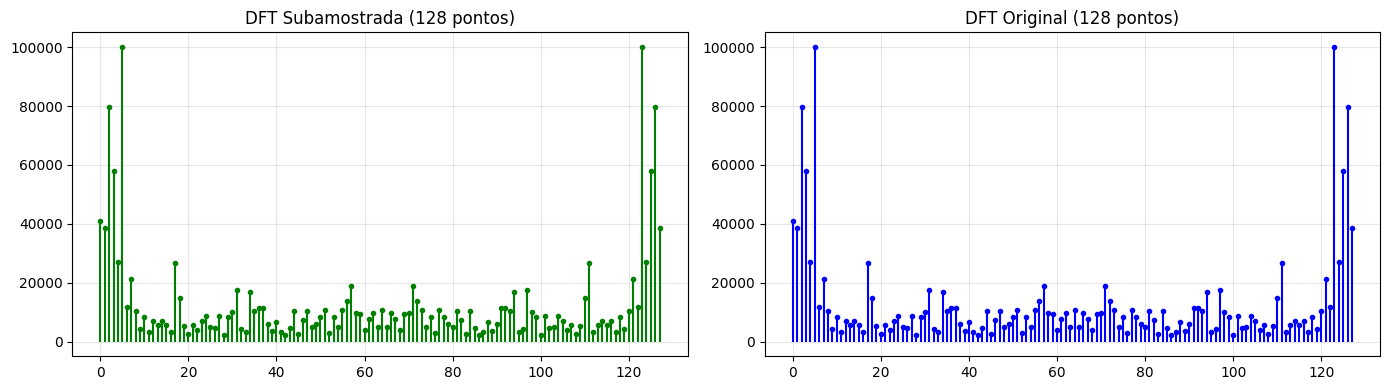

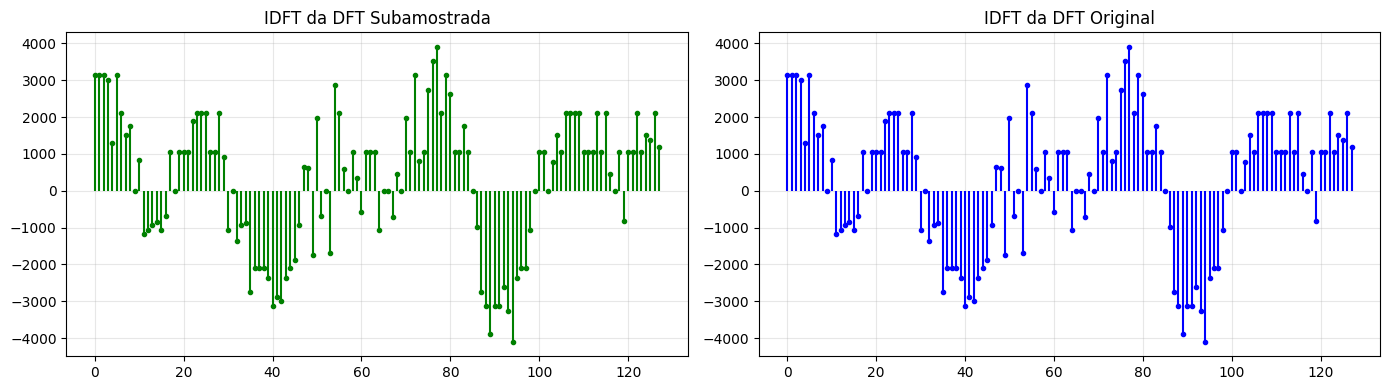


✅ PROCESSAMENTO CONCLUÍDO COM SUCESSO!
   Erro na frequência: 0.00e+00 (Como é menor que 1e-10, as sequências SÃO IGUAIS)
   Erro no tempo     : 0.00e+00 (Como é menor que 1e-10, as sequências SÃO IGUAIS)


In [11]:
# =====================================================================
# IMPORTAÇÃO DAS BIBLIOTECAS NECESSÁRIAS
# =====================================================================
import numpy as np               # Biblioteca principal para cálculos matemáticos e manipulação de vetores/matrizes
import matplotlib.pyplot as plt  # Biblioteca para plotar os gráficos (funções stem e plot)
from scipy.io import wavfile     # Função específica para ler e decodificar arquivos de áudio .wav
from google.colab import files   # Módulo exclusivo do Google Colab para criar o botão de upload de arquivos

# =====================================================================
# 1. DEFINIÇÃO DAS FUNÇÕES MATEMÁTICAS BASE (Sem usar FFT pronta)
# =====================================================================

def calcular_dft(x):
    """
    Calcula a Transformada Discreta de Fourier (DFT) implementando a equação do somatório.
    Fórmula: X[k] = sum(x[n] * exp(-j * 2*pi * k * n / N))
    """
    N_len = len(x)                                 # Descobre o tamanho N do sinal de entrada
    n = np.arange(N_len)                           # Cria o vetor de tempo n = [0, 1, 2, ..., N-1]
    k = n.reshape((N_len, 1))                      # Cria o vetor de frequência k (como uma coluna para gerar uma matriz na multiplicação)

    # Cria a matriz de transformação W com as exponenciais complexas
    W = np.exp(-2j * np.pi * k * n / N_len)        # 2j no Python representa 2 * número imaginário (j)

    # Multiplica a matriz W pelo vetor x para fazer o somatório de todas as amostras de uma vez
    return np.dot(W, x)

def calcular_idft(X):
    """
    Calcula a Transformada Inversa Discreta de Fourier (IDFT) implementando a equação do somatório.
    Fórmula: x[n] = (1/N) * sum(X[k] * exp(j * 2*pi * k * n / N))
    """
    N_len = len(X)                                 # Descobre o tamanho N do espectro de frequências
    n = np.arange(N_len)                           # Cria o vetor de tempo n
    k = n.reshape((N_len, 1))                      # Cria o vetor de frequência k

    # Cria a matriz W inversa (note que o sinal da exponencial agora é positivo, sem o '-')
    W_inv = np.exp(2j * np.pi * k * n / N_len)

    # Multiplica a matriz pelo sinal e divide tudo por N (regra da IDFT)
    return np.dot(W_inv, X) / N_len

# =====================================================================
# 2. FUNÇÃO PRINCIPAL QUE AUTOMATIZA A QUESTÃO 4 (Itens a, b e c)
# =====================================================================
def analisar_sinal(x_n, K=512, D=4, nome_sinal="Sinal", plotar_graficos=True):
    N = len(x_n) # Pega o tamanho do sinal original (esperado: 128)

    # -----------------------------------------------------------------
    # ITEM (a): Zero-padding e cálculo da DFT de 512 pontos
    # -----------------------------------------------------------------
    # O comando np.pad pega o vetor x_n e adiciona zeros no final.
    # (0, K - N) significa: "adicione 0 zeros no começo, e (512-128 = 384) zeros no final".
    x_e = np.pad(x_n, (0, K - N), 'constant')

    # Calcula a DFT do sinal com zeros. Isso interpola a frequência (aumenta a resolução para 2*pi/512).
    X_e = calcular_dft(x_e)

    # -----------------------------------------------------------------
    # ITEM (b): Subamostragem no domínio da frequência
    # -----------------------------------------------------------------
    # [::D] no Python é um recurso de "slicing" que pega os elementos pulando de D em D passos.
    # Como D=4, ele pega o índice 0, 4, 8, 12... reduzindo de 512 para 128 pontos.
    X_e_sub = X_e[::D]

    # Calcula a DFT diretamente do sinal original x_n (sem zero-padding) para servir de gabarito.
    X_k = calcular_dft(x_n)

    # Calcula o erro máximo (a maior diferença entre qualquer ponto da DFT subamostrada e da Original).
    # Se a diferença for próxima de zero (ex: 1e-14), significa que são matematicamente iguais.
    erro_b = np.max(np.abs(X_e_sub - X_k))

    # -----------------------------------------------------------------
    # ITEM (c): Retorno ao tempo via Transformada Inversa (IDFT)
    # -----------------------------------------------------------------
    # Aplica a IDFT no espectro subamostrado.
    # O .real no final descarta o resíduo imaginário gerado por arredondamento de máquina, pois áudio é real.
    x_idft_sub = calcular_idft(X_e_sub).real

    # Aplica a IDFT no espectro original (gabarito).
    x_idft_orig = calcular_idft(X_k).real

    # Calcula a maior diferença no domínio do tempo para verificar se ambos voltaram ao sinal original perfeitamente.
    erro_c = np.max(np.abs(x_idft_sub - x_idft_orig))

    # -----------------------------------------------------------------
    # GERAÇÃO DOS GRÁFICOS (Se a variável plotar_graficos for True)
    # -----------------------------------------------------------------
    if plotar_graficos:
        print(f"\n--- Gerando gráficos para: {nome_sinal} ---")

        # --- Gráficos do Item (a) ---
        plt.figure(figsize=(14, 4))                # Cria uma figura com largura 14 e altura 4

        plt.subplot(1, 2, 1)                       # Divide a tela: 1 linha, 2 colunas, seleciona a posição 1
        plt.stem(np.arange(K), x_e, basefmt=" ", markerfmt="b.") # Plota o sinal em hastes (tempo discreto)
        plt.title(f"Sequência $x_e[n]$ com Zero-padding ({nome_sinal})")
        plt.grid(True, alpha=0.3)                  # Coloca a grade ao fundo do gráfico

        plt.subplot(1, 2, 2)                       # Seleciona a posição 2 (direita)
        plt.plot(np.arange(K), np.abs(X_e), 'r')   # Plota a magnitude (módulo) da DFT usando uma linha contínua vermelha
        plt.title(f"Magnitude DFT: $|X_e[k]|$ ({K} pontos)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()                         # Ajusta os espaçamentos para não encavalar os textos
        plt.show()                                 # Exibe os gráficos na tela

        # --- Gráficos do Item (b) ---
        plt.figure(figsize=(14, 4))
        plt.subplot(1, 2, 1)
        plt.stem(np.arange(len(X_e_sub)), np.abs(X_e_sub), linefmt='g-', markerfmt='g.', basefmt=" ")
        plt.title(f"DFT Subamostrada ({len(X_e_sub)} pontos)")
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.stem(np.arange(len(X_k)), np.abs(X_k), linefmt='b-', markerfmt='b.', basefmt=" ")
        plt.title(f"DFT Original ({len(X_k)} pontos)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # --- Gráficos do Item (c) ---
        plt.figure(figsize=(14, 4))
        plt.subplot(1, 2, 1)
        plt.stem(np.arange(len(x_idft_sub)), x_idft_sub, linefmt='g-', markerfmt='g.', basefmt=" ")
        plt.title("IDFT da DFT Subamostrada")
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.stem(np.arange(len(x_idft_orig)), x_idft_orig, linefmt='b-', markerfmt='b.', basefmt=" ")
        plt.title("IDFT da DFT Original")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # A função finaliza devolvendo os valores dos erros numéricos encontrados
    return erro_b, erro_c


# =====================================================================
# 3. ROTINA DE EXECUÇÃO: FASE 1 - TESTE AUTOMATIZADO COM IMPULSO
# =====================================================================
print("="*60)
print("INICIANDO FASE 1: TESTE DE VALIDAÇÃO MATEMÁTICA (Impulso)")
print("="*60)

# Cria um sinal artificial tipo Impulso Unitário (delta de Dirac discreto)
N_teste = 128
x_impulso = np.zeros(N_teste)                      # Cria um vetor de 128 zeros
x_impulso[0] = 1.0                                 # Coloca o valor 1.0 na primeira posição (n=0)

# Chama a função de análise enviando o impulso, mas desliga a plotagem gráfica
erro_b_teste, erro_c_teste = analisar_sinal(x_impulso, plotar_graficos=False)

# Define um limite muito pequeno para aceitar o erro de cálculo do computador (10 elevado a -10)
tolerancia = 1e-10

# Se o erro for menor que a tolerância, passou no teste. Se não, o programa acusa erro matemático e para.
if erro_b_teste < tolerancia and erro_c_teste < tolerancia:
    print("✅ TESTE APROVADO!")
    print(f"   Erro na frequência (Item b): {erro_b_teste:.2e}")
    print(f"   Erro no tempo (Item c)     : {erro_c_teste:.2e}")
    print("   Os cálculos de DFT, Zero-Padding e Subamostragem estão consistentes.\n")
else:
    raise ValueError(f"❌ TESTE FALHOU! Erros encontrados: b={erro_b_teste:.2e}, c={erro_c_teste:.2e}. Verifique as equações.")

# =====================================================================
# 4. ROTINA DE EXECUÇÃO: FASE 2 - PROCESSAMENTO DO ÁUDIO REAL
# =====================================================================
print("="*60)
print("INICIANDO FASE 2: PROCESSAMENTO DO ÁUDIO (Questão 4)")
print("="*60)

# Abre a janela de upload do Colab para o usuário enviar o arquivo de áudio
print("Por favor, faça o upload do arquivo 'forcewithyou.wav' (ou outro .wav equivalente):")
uploaded = files.upload()

# Pega o nome exato do arquivo que o usuário acabou de enviar (ex: 'forcewithyou.wav')
nome_arquivo = list(uploaded.keys())[0]

# Lê o arquivo WAV. Retorna a frequência de amostragem (fs) e os dados de áudio em um vetor (data)
fs, data = wavfile.read(nome_arquivo)

# Verifica se a matriz de áudio tem mais de uma dimensão (ou seja, se é estéreo)
if len(data.shape) > 1:
    data = data[:, 0]                              # Descarta a segunda coluna para trabalhar com áudio Mono

# Conforme pedido no enunciado (a), recorta uma sequência de N=128 começando na amostra 1201
n_start = 1201
N_audio = 128
x_audio = data[n_start : n_start + N_audio]

# Chama a nossa função principal passando o recorte de áudio e ligando os gráficos
erro_b_audio, erro_c_audio = analisar_sinal(x_audio, nome_sinal="Áudio wav", plotar_graficos=True)

# Imprime o laudo final com a constatação pedida pelo professor nos itens b e c ("informe se são iguais")
print(f"\n✅ PROCESSAMENTO CONCLUÍDO COM SUCESSO!")
print(f"   Erro na frequência: {erro_b_audio:.2e} (Como é menor que 1e-10, as sequências SÃO IGUAIS)")
print(f"   Erro no tempo     : {erro_c_audio:.2e} (Como é menor que 1e-10, as sequências SÃO IGUAIS)")

O objetivo da questão, é justamente provar, na prática, uma propriedade matemática de Processamento de Sinais: o zero-padding no domínio do tempo equivale a uma interpolação no domínio da frequência.

Aqui está o que acontece matematicamente nos bastidores:

1. O sinal original ($N=128$): Ao calcular a DFT do sinal original de 128 amostras, você está pegando o espectro contínuo de frequências desse áudio (a DTFT) e "tirando uma foto" dele em 128 pontos igualmente espaçados. A distância (resolução) entre cada ponto é de $\frac{2\pi}{128}$.

2. O zero-padding ($K=512$): Ao criar $x_e[n]$ adicionando 384 zeros no final do áudio, você não está adicionando nenhuma informação sonora nova. Um silêncio não muda as frequências de um som que já aconteceu. O que o zero-padding faz na DFT é apenas recalcular a mesma curva de frequências com mais "pontinhos" (maior resolução). A distância entre os pontos cai para $\frac{2\pi}{512}$. A curva fica mais suave, mas a "essência" do espectro é idêntica.

3. A subamostragem ($D=4$): Se a DFT com zeros tem uma resolução de $\frac{2\pi}{512}$, e você subamostra isso pegando apenas uma a cada 4 amostras (pulando de 4 em 4), veja a matemática:$$4 \times \frac{2\pi}{512} = \frac{8\pi}{512} = \frac{2\pi}{128}$$

Ou seja, ao dar "pulos" maiores na DFT esticada, você "pousa" cirurgicamente em cima dos exatos mesmos pontos da sua DFT original de 128 amostras! É por isso que as amplitudes e os formatos das duas hastes nos seus gráficos bateram perfeitamente. Consequentemente, ao fazer o item (c) e aplicar a IDFT (Transformada Inversa) em ambas, as duas obrigatoriamente retornarão o exato mesmo pedaço do áudio original no domínio do tempo.